# Pandas e scikit-learn

## Pandas

Pands fornisce strutture dati di alto livello come DataFrame e Series, che sono più flessibili e facili da usare rispetto agli array NumPy. Queste strutture rendono più semplice organizzare e analizzare dati tabellari.

In [86]:
import pandas as pd
import numpy as np

# inizializzo il dataset come dizionario
# le chiavi sono i nomi delle colonne
mio_dataset = {
    'nomi' : np.array(['Marco', 'Francesca', 'Diletta', 'David', 'Fasil']),
    'ages' : np.array([20, 22, 21, 23, 20]),
    'scores' : np.array([85, 92, 78, 95, 88])
}

df = pd.DataFrame( mio_dataset )
df

,nomi,ages,scores
0,Marco,20,85
1,Francesca,22,92
2,Diletta,21,78
3,David,23,95
4,Fasil,20,88


Dataframes pandas sono strutture bidimensionali che contengono una o più colonne. Le colonne a loro volta sono Series, ovvero oggetti unidimensionali.

In [87]:
print(f"DataFrame:\t\t\t\t{type(df)}")
print('\n')
print(f"Colonna ages, cioè: DataFrame['ages']\t{type(df['ages'])}")

DataFrame:				<class 'pandas.core.frame.DataFrame'>


Colonna ages, cioè: DataFrame['ages']	<class 'pandas.core.series.Series'>


In [88]:
df["ages"] + 3 # incremento di 3 ogni elemento della colonna "ages"

,ages
0,23
1,25
2,24
3,26
4,23


In [89]:
res = df["ages"] + df["scores"] # sommo tra loro le due colonne
res

,0
0,105
1,114
2,99
3,118
4,108


In [90]:
res = df[ df["nomi"] == "David" ] # seleziona le righe che soddisfano la condizione
res

,nomi,ages,scores
3,David,23,95


In [91]:
res = df[ df["scores"] > 90 ]  # seleziona le righe che soddisfano la condizione
res

,nomi,ages,scores
1,Francesca,22,92
3,David,23,95


In [92]:
res = df[ ( df["scores"] > 80 ) & ( df["scores"] < 90 ) ] # seleziono le righe che soddisfano la condizione
res

,nomi,ages,scores
0,Marco,20,85
4,Fasil,20,88


In [93]:
# Aggiungere una nuova colonna al df
# Es)
np.random.seed(42)
df["nuova"] = np.random.randint(0, 10, df.shape[0])
df

,nomi,ages,scores,nuova
0,Marco,20,85,6
1,Francesca,22,92,3
2,Diletta,21,78,7
3,David,23,95,4
4,Fasil,20,88,6


In [94]:
# Aggiungere una nuova colonna come elaborazione di un'altra colonna che già ho sul dataframe
df['nuova_2'] = df['ages'] + 5
df

,nomi,ages,scores,nuova,nuova_2
0,Marco,20,85,6,25
1,Francesca,22,92,3,27
2,Diletta,21,78,7,26
3,David,23,95,4,28
4,Fasil,20,88,6,25


### Utilities per Pre-processing dei dati

In [95]:
# Creazione di un DataFrame fittizio con errori

data = {
    'Nome' :       ['Alice', 'Serenella', 'Bob', 'Diletta', 'David', np.nan, 'Charlie', np.nan, 'Aldo', 'Eve'],
    'Eta' :        [25, 30, 22, np.nan, 35, 28, np.nan, 24, 16 ,31],
    'Punteggio' :  [85, 92, 90, 78, 64, 36, 99, 88, 58 ,60],
    'Sesso' :      ['F', 'F', 'M', 'F', 'M', 'M', 'M', 'F', 'M','F'],
    'Indirizzo' :  ['123 Main St', '456 Elm St', np.nan, '789 Oak St', '555 Pine St', np.nan, '999 Maple St',
                   '111 Awk St', '321 Bolo St', '444 Second St'],
    'Nazionalita': ['USA', 'Canada', 'UK', 'USA', 'Germany', 'France', 'UK', 'USA', 'Italy' , 'Italy']
}

df = pd.DataFrame( data )

# Visualizzazione del dataframe con errori
print('Dataframe con errori:')
print( df )




Dataframe con errori:
        Nome   Eta  Punteggio Sesso      Indirizzo Nazionalita
0      Alice  25.0         85     F    123 Main St         USA
1  Serenella  30.0         92     F     456 Elm St      Canada
2        Bob  22.0         90     M            NaN          UK
3    Diletta   NaN         78     F     789 Oak St         USA
4      David  35.0         64     M    555 Pine St     Germany
5        NaN  28.0         36     M            NaN      France
6    Charlie   NaN         99     M   999 Maple St          UK
7        NaN  24.0         88     F     111 Awk St         USA
8       Aldo  16.0         58     M    321 Bolo St       Italy
9        Eve  31.0         60     F  444 Second St       Italy


Come vedo, nel dataframe ho una serie di problemi, come i valori nulli. Usare questi dati direttamente sui miei modelli, probabilmente mi arreca errori molto grossi per cui i miei modelli non riescono a convergere verso la soluzione.
Quindi, è molto importante svolgere la parte di pre-processing, come scartare le righe che contengono i valori nulli, o perlomento andarle a riempire con dei valori che non vanno ad inficiare troppo le distribuzione dei dati.

In [96]:
## Pulizia dei dati

# 1. Rimozione delle righe con valori mancanti
df = df.dropna()

# 2. Rimozione dei duplicati
df = df.drop_duplicates() # li rimuovo perchè andrebbero altrimenti a modificare la distribuzione del dataset

#3. Trasformazione dei valori in modo coerente (ad esempio, età in interi)
df['Eta'] = df['Eta'].astype(int) # è importante avere i tipi corretti

#4. Validazione dei dati:
# (ad esempio, potrei verficiare che l'età sia compresa tra 18 e 99)
df = df[ (df['Eta'] >= 18) & (df['Eta'] <= 99) ] # quest'operazione dipende dalle specifiche del problema

#5. Correzione di errori specifici
# (ad esempio, potrei correggere un valore errato nell'indirizzo)
df.loc[ df['Nome'] == 'David', 'Indirizzo' ] = '567 Cedar St' # prendi la riga che riguarda 'David', e cambia l'indirizzo

# 6. Trasformare M ed F in booleani True o False
# Creo una nuova colonna 'Donna' dove ho True se sesso 'F', False se 'M'
df['Donna'] = df['Sesso'] == 'F'

# 7. Categorizzare automaticamente le nazionalità
# in pratica trasformo la nazionalita' in categoria: i miei modelli solitamente non riescono a leggere le stringhe e,
# ad esempio in questo caso, per differenziare una nazionalità rispetto a un'altra è utile andare a fare il one-hot
# encoding, in cui si trasforma una lista in valori numerici
df['Nazionalita'] = df['Nazionalita'].astype('category').cat.codes

# Visualizzazione del DataFrame pulito
print('\nDataFrame pulito:')
print( df )


DataFrame pulito:
        Nome  Eta  Punteggio Sesso      Indirizzo  Nazionalita  Donna
0      Alice   25         85     F    123 Main St            3   True
1  Serenella   30         92     F     456 Elm St            0   True
4      David   35         64     M   567 Cedar St            1  False
9        Eve   31         60     F  444 Second St            2   True


## Scikit-learn


In [97]:
import sklearn

from sklearn.datasets import load_iris

iris_dataset_np = load_iris() # ritorna un oggetto che contiene due numpy
x_np, y_np = iris_dataset_np.data, iris_dataset_np.target

# x_np è un tipo numpy
# y_np è un tipo numpy

iris_dataset_pd = load_iris(as_frame=True)
x_pd, y_pd = iris_dataset_pd.data, iris_dataset_pd.target

# x_pd è un DataFrame pandas
# y_pd è una Series pandas

x_pd

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


Iris Analisi Dati Esplorativa

In [98]:
df = x_pd.copy()
df['Targets'] = y_pd # creo una nuova colonna di nome targets e la aggiungo al df
# nel DS iris ho tre classi, rappresentate da 0,1,2
df.head(10) # stampa le prime 10 righe

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Targets
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Voglio raggruppare i dati per avere delle statistiche descrittive

In [99]:
df.describe() # computa le statistiche sui dati

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Targets
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Come vedo, questa mi mostra sia i valori medi, che la standard deviation e i valori percentili.

Provo a mostrare le distribuzioni dei dati sul grafo.

Lo faccio tramite data visualization. In particolare, faccio uno scatterplot in cui confronto due features del dataset, in particolare petal length e petal width in cm.


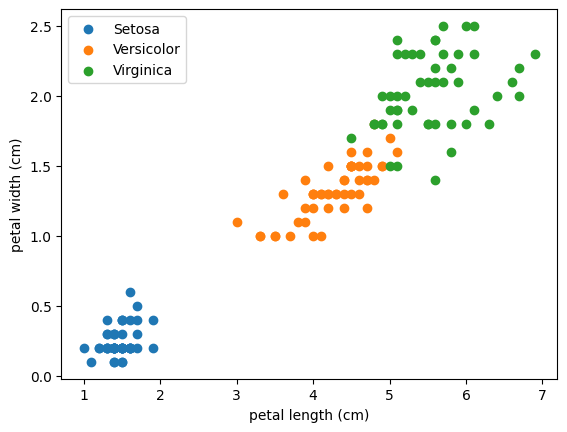

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

map_dict = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['Species'] = df['Targets'].map(map_dict)

def scatter_plot(df, x_name, y_name):
  for species, gruppo in df.groupby("Species"):
    plt.scatter( gruppo[x_name], gruppo[y_name], label=species )

  # Mostra il grafico
  plt.legend()
  plt.xlabel(x_name)
  plt.ylabel(y_name)
  plt.show()

scatter_plot( df, x_name="petal length (cm)", y_name="petal width (cm)" )

I vari colori rappresentano le classi dei miei dati, e il loro posizionamento dipende dal valore del dato.
Come si vede, è già colorato con solo la lunghezza e larghezza del petalo.

Gurado la stessa cosa, però rispetto alla lunghezza del sepalo:

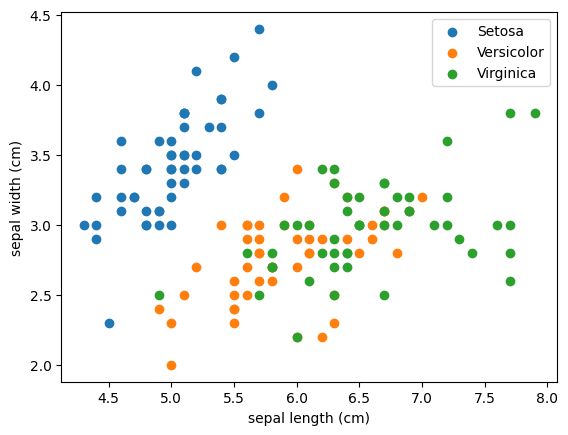

In [101]:
scatter_plot( df, x_name="sepal length (cm)", y_name="sepal width (cm)" )

Qui si vede che Setosa è già abbastanza ben suddividibile anche con un classificatore lineare, invece per Versicolar la faccenda è già più complessa.

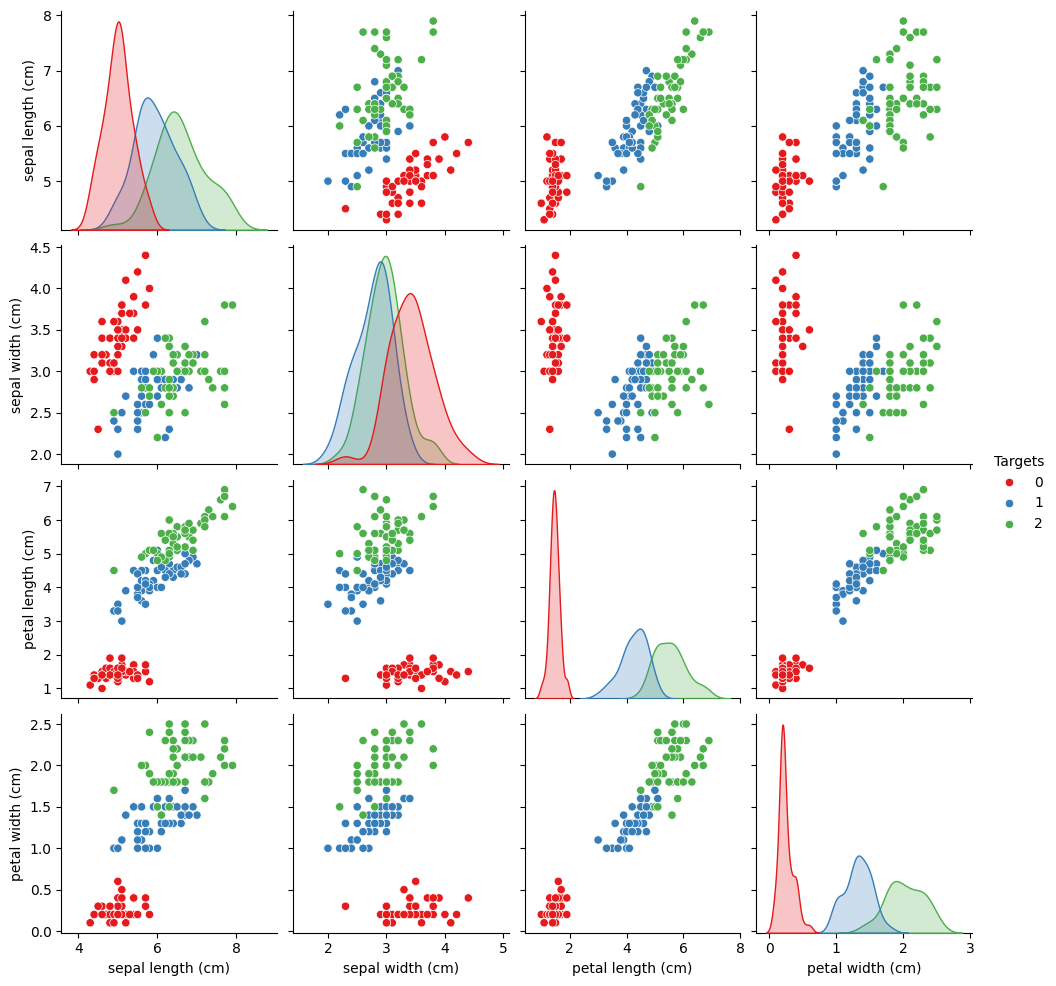

In [102]:
sns.pairplot(df, hue='Targets', palette='Set1')

Grazie a seaborn, e alla funzione `pairplot`, riesco a mettere a confronto le features del dataset a coppie, e mi permette appunto di stampare questo tipo di grafici che ho qui sopra.

Come vedo, sulla diagonale principale ho una distribuzione monovariata delle variabili che appunto si intersecano sulla diagonale.

Gli altri sono invece degli scatterplot che mi vengono rappresentati a coppie, con una feature e l'altra.

Correlazioni lineari tra le variabili dentro il mio dataset.

Anche in questo caso, vedo la correlazione lineare a coppie:

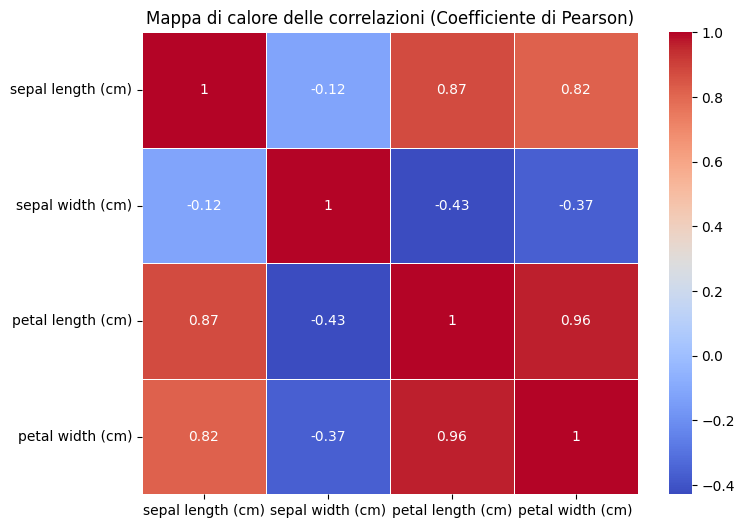

In [103]:
# con il coefficiente di Pearson
correlation_matrix = df[ df.columns[:-2]].corr(method='pearson')

# Creazione di una mappa di calore
plt.figure( figsize=(8, 6) )
sns.heatmap( correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5 )
plt.title('Mappa di calore delle correlazioni (Coefficiente di Pearson)')
plt.show()

Ho che, se il valore è positivo (il massimo è 1), allora ho una correlazione positiva tra le variabili in considerazione.

Invece, se il valore è negativo (il minimo è -1), allora ho che le variabili sono diversamente proporzionate.

Chiaramente, sulla diagonale il valore è 1.

Invece, se il valore dovesse essere 0 vuol dire che sono completamente scorrelate.

### Creazione di nuovi Dataset tramite funzioni built-in di scikit learn

Vado a vedere la creazione di dataset di a forma di:
- blob
- luna
- curva ad s
- cerchio

In pratica, lo scopo è di partire non avendo nulla, e quello che voglio fare è di crearmi dei dati con delle distribuzioni che voglio io.
C'è la possibilità di scegliere queste distribuzioni. Solitamente vengono usati i Blob, che è la rappresentazione che solitamente si ha dei dati.

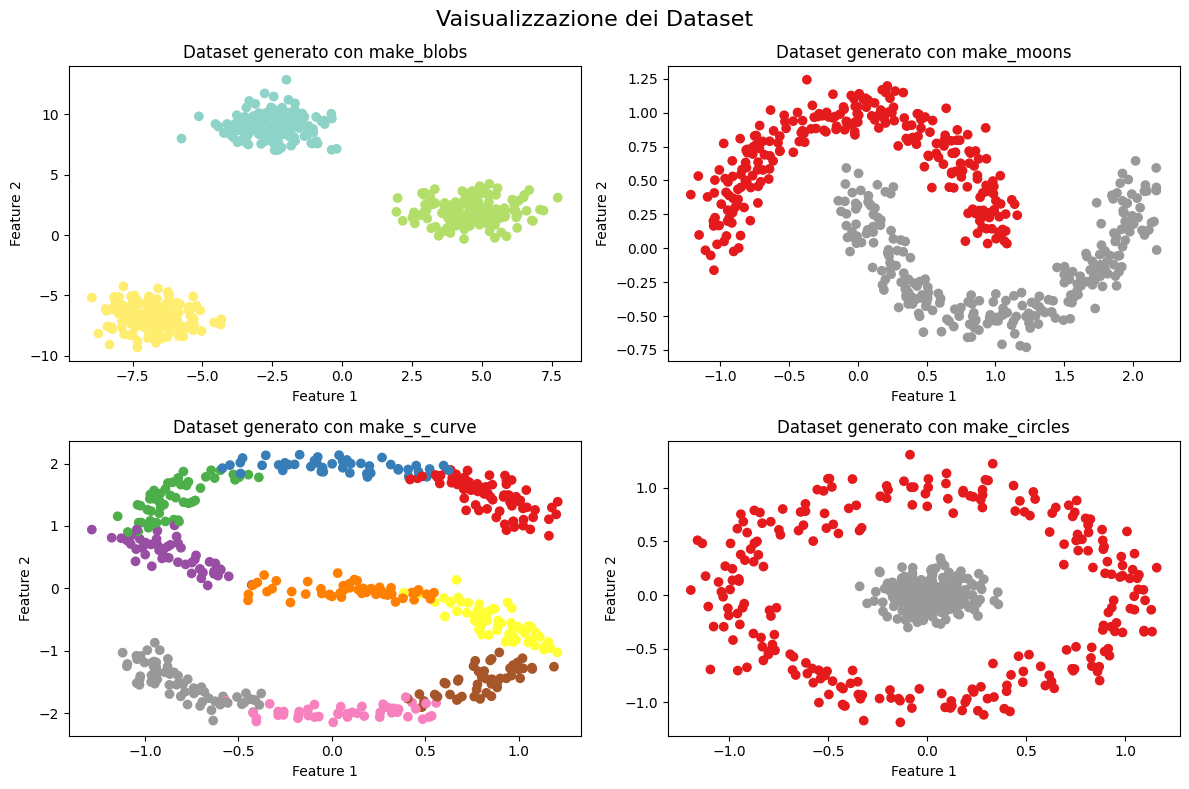

In [106]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_s_curve, make_circles


# Qui metto alcuni parametri che servono per impostare come voglio creare i dati
# che vengono creati
n_samples = 500
n_features = 2
random_seed = 42
noise_factor = 0.1

# Genera il dataset con make_blobs
X_blobs, y_blobs = make_blobs(n_samples=n_samples, n_features=n_features, centers=3, random_state=random_seed)

# Genera il dataset con make_moons
X_moons, y_moons = make_moons(n_samples=n_samples, noise=noise_factor, random_state=random_seed)

# Genera il dataset con make_s_curve
X_s_curve, y_s_curve = make_s_curve(n_samples=n_samples, noise=noise_factor, random_state=random_seed)

# Genera il dataset con make_circles
X_circles, y_circles = make_circles(n_samples=n_samples, noise=noise_factor, factor=0.1, random_state=random_seed)


# Creo il grafico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Vaisualizzazione dei Dataset', fontsize=16)

# Plot per make_blobs
axes[0, 0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='Set3')
axes[0, 0].set_xlabel("Feature 1")
axes[0, 0].set_ylabel("Feature 2")
axes[0, 0].set_title('Dataset generato con make_blobs')


# Plot per make_moons
axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='Set1')
axes[0, 1].set_xlabel("Feature 1")
axes[0, 1].set_ylabel("Feature 2")
axes[0, 1].set_title('Dataset generato con make_moons')

# Plot per make_s_curve
axes[1, 0].scatter(X_s_curve[:, 0], X_s_curve[:, 2], c=y_s_curve, cmap='Set1')
axes[1, 0].set_xlabel("Feature 1")
axes[1, 0].set_ylabel("Feature 2")
axes[1, 0].set_title('Dataset generato con make_s_curve')


# Plot per make_circles
axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='Set1')
axes[1, 1].set_xlabel("Feature 1")
axes[1, 1].set_ylabel("Feature 2")
axes[1, 1].set_title('Dataset generato con make_circles')

plt.tight_layout()
plt.show()




Appunto:
- make_blobs: mi consente di creare un dataset che ha dei blobs ben separati l'uno dall'altro. posso anche definire quanto i dati dentro i blobs sono raggruppati o quanto sono sparsi.
- funzionamento simile per gli altri.

#### Dataset Fetchers

Mi permettono di scaricare dataset più corposi e usati solitamente per creare applicazioni di IA.

In questo caso mi scarico un dataset che contiene le facce di persone.

In [108]:
from sklearn.datasets import fetch_lfw_people

data2 = fetch_lfw_people(color=True) # False ritorna in scala di grigi

# Estrai le immagini e le etichette
X = data2.images
y = data2.target

# Stampare le dimensioni dei dati
print(f'Dimensione dei dati: {X.shape}')
print(f'Dimensione delle etichette: {y.shape}')



Dimensione dei dati: (13233, 62, 47, 3)
Dimensione delle etichette: (13233,)


(13233, 62, 47, 3) ==> mi dice che ho 13233 esempi, e che le immagini sono
67x47 in 3 canali.

Visualizzo un'immagine

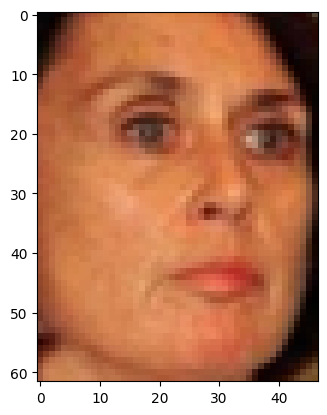

In [109]:
plt.imshow(X[5])
plt.show()

Vedo ora i valori che sono contenuti dentro la mia immagine

In [111]:
print(f'Img shape: {X[0].shape}')
print(f'Min: {np.min(X)}')
print(f'Max: {np.max(X)}')
print(f'Dtype: {X.dtype}')

# Come faccio a trasformarli in scala di grigi? ==> come visto, faccio la media sugli assi

Img shape: (62, 47, 3)
Min: 0.0
Max: 1.0
Dtype: float32


Img shape: (62, 47)
Min: 0.0
Max: 1.0
Dtype: float32


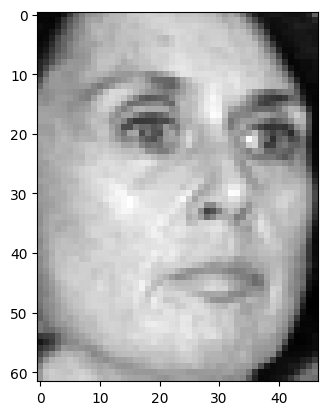

In [113]:
# Per trasformarli in scala di grigi devo fare la media sugli assi (sugli assi dei canali)
x_gray = np.mean( X, axis=-1 )

print(f'Img shape: {x_gray[0].shape}')
print(f'Min: {np.min( x_gray )}')
print(f'Max: {np.max( x_gray )}')
print(f'Dtype: {x_gray.dtype}')

plt.imshow( x_gray[5], cmap="gray" )
plt.show()

### Data Preprocessing

1. Normalizzazione
2. Sbilanciamento delle classi
3. Train Test split stratificato


**Dataset Normalization**

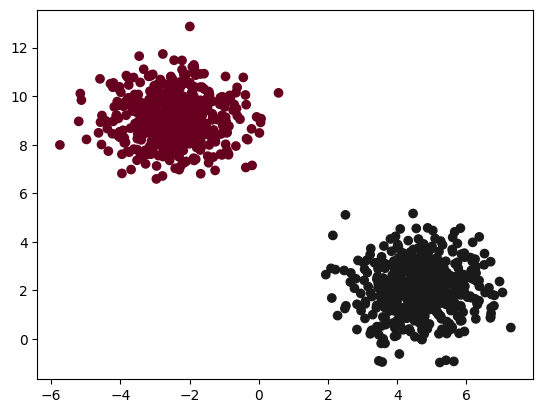

In [115]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Parametri per generare un dataset
n_samples = 1000
n_features = 2
n_classes = 2
random_seed = 42
noise_factor = 0.1 # rumore per la distribuzione

# Genero il dataset con make_blobs
X, y = make_blobs( n_samples=n_samples, n_features=n_features, centers=n_classes, random_state=random_seed )

# Plotto il dataset originale
plt.scatter( X[:, 0], X[:, 1], c=y, cmap='RdGy')
plt.show()

Questa è la distribuzione del mio DS, rappresentato completamente da queste due variabili, e vedo che è ben suddiviso.

> Quindi, ho una distribuzione e voglio Normalizzarla per dare a tutte le features la stessa scala.

Questo è importante perchè nei modelli di IA non posso usare dei valori da -inf a +inf, perchè con dei valori troppo grandi il modello fa fatica a convergere.

Quindi si usano tecniche come la normalizzazione, o gli scaler per portare le features in intervalli che possono essere ben appresi dai modelli.

In particolare, si cerca di avere valori abbastanza piccoli (intorno allo 0, o che partono da 0).

- standard scaler: scala ogni valore del DS andando a sottrarne la media e dividendo per la varianza. Questo mi permette di:
  - la sottrazione mi porta ogni valore intorno allo zero
  - dividendo per la standard deviation vado a compattare i valori del dataset.
  

- min max scaler: sottraggo per il minimo e divido per il massimo - il minimo. Così facendo vado a impostare il range dei valori compresi tra 0 ed 1.

- max abs scaler: divido per il valore assoluto del valore massimo del set di dati.

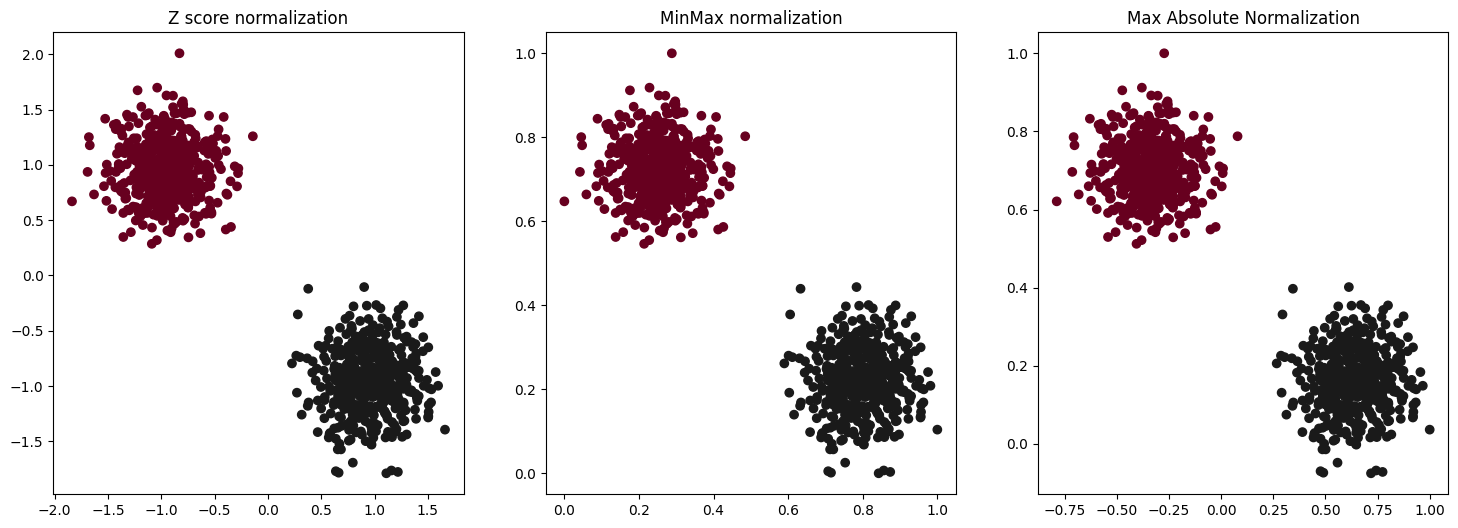

In [117]:
# dataset preprocessing
from sklearn import preprocessing

zScoreScaler = preprocessing.StandardScaler() # z = (x - media) / dev_standard
minMaxScaler = preprocessing.MinMaxScaler() # z = (x-x_min) / (x_max-x_min) : range [0, 1]
maxAbsScaler = preprocessing.MaxAbsScaler() # z = x / Abs(x_max)

scalers = [zScoreScaler, minMaxScaler, maxAbsScaler]
titles = ["Z score normalization", "MinMax normalization", "Max Absolute Normalization"]

num_cols = len( scalers )
fig_width = 6 #Aggiustare questo valore se necessario
fig_height = fig_width * num_cols
fig, axs = plt.subplots( 1, num_cols, figsize=(fig_height, fig_width) )

for i, (title, scaler) in enumerate( zip( titles, scalers ) ):
  # General api interface
  scaler.fit( X )
  X_scaled = scaler.transform( X )
  axs[i].scatter( X_scaled[:,0], X_scaled[:, 1], c=y, cmap="RdGy" )
  axs[i].set_title( title )

plt.show()

Sembrano apparentemente gli stessi valori, però hanno tutti delle scale diverse.
- Z score normalization: ho il valore medio a 0, e i valori sono distribuiti tutti intorno allo 0.
- MinMax normalization: tutti i valori sono compresi tra [0, 1]
- MaxAbsolute normalization: divido ogni valore per il assoluto del massimo, ma con questa vado a preservare la dispersione dei dati.

Per ogni utilizzo di tecnica è importante fare delle prove e verificare quale tecnica risulta meglio sul mio set di dati. Non c'è mai una cosa che va bene per tutto. Quello che devo fare è:
- provare e vedere come si comporta il mio modello in base a come ho i dati